In [1]:
# Imports 
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [3]:
# Load data
house_df = pd.read_csv("C:\\Users\\HP\\Desktop\\labsheet mca\\Housing.csv")
print("Shape:", house_df.shape)
print(house_df.head())

Shape: (545, 13)
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [4]:
# Data understanding
house_df.info()
print("Missing values:", house_df.isnull().sum().sum())
print("Duplicates:", house_df.duplicated().sum())
print(house_df.describe().T)

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 69.2 KB
Missing values: 0
Duplicates: 0
           count          mean           std        min        25%        50%  \
price      545.0  4.766729e+06  1.870440e+06  1750000.0  3430000.0  434

In [5]:
# Cleaning and preprocessing
house_df = house_df.drop_duplicates().dropna().reset_index(drop=True)

yes_no_columns = ["mainroad", "guestroom", "basement",
                  "hotwaterheating", "airconditioning", "prefarea"]
for column in yes_no_columns:
    house_df[column] = house_df[column].str.strip().str.lower().map({"yes": 1, "no": 0})

# Outlier removal on price using the IQR rule
q1, q3 = house_df["price"].quantile([0.25, 0.75])
upper_limit = q3 + 1.5 * (q3 - q1)
rows_before = len(house_df)
house_df = house_df[house_df["price"] <= upper_limit].reset_index(drop=True)
print(f"Removed {rows_before - len(house_df)} price outliers. Rows left: {len(house_df)}")

Removed 15 price outliers. Rows left: 530


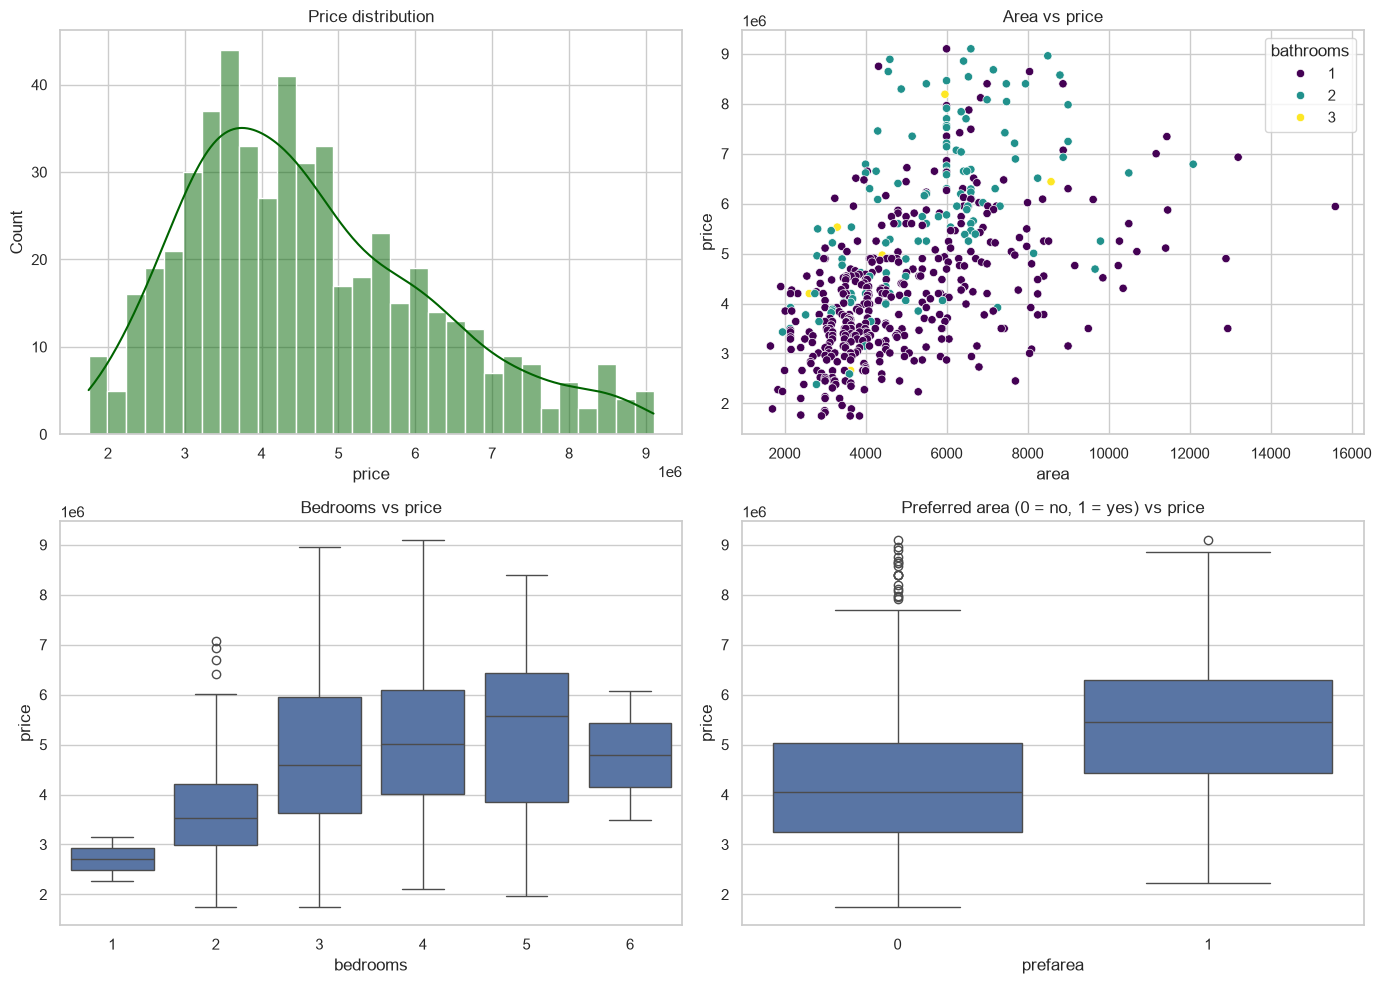

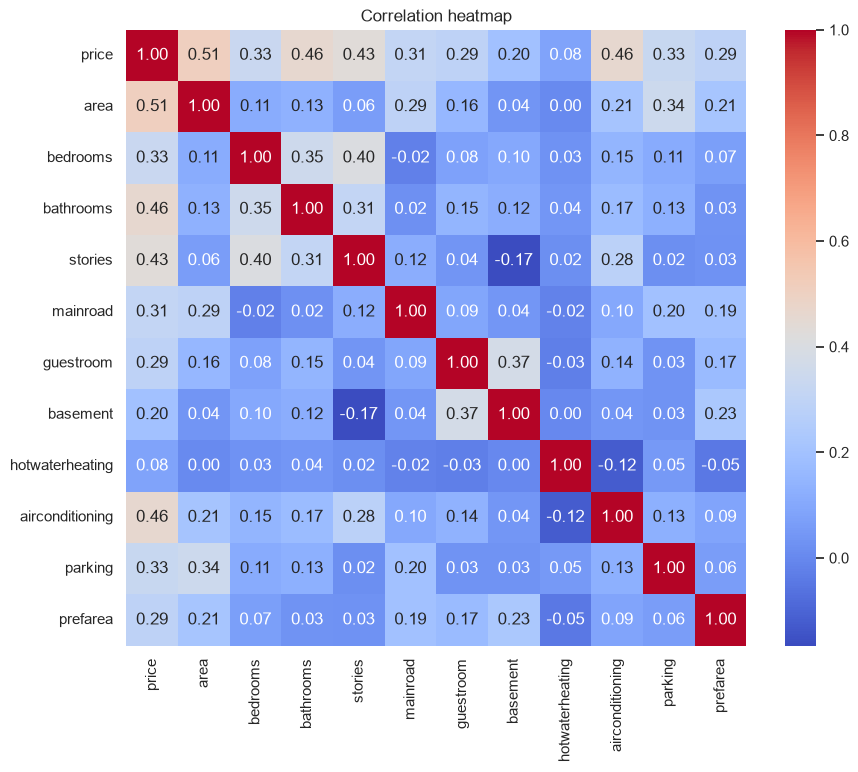

In [6]:
# EDA 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(house_df["price"], bins=30, kde=True, ax=axes[0, 0], color="darkgreen")
axes[0, 0].set_title("Price distribution")
sns.scatterplot(data=house_df, x="area", y="price", hue="bathrooms",
                palette="viridis", ax=axes[0, 1])
axes[0, 1].set_title("Area vs price")
sns.boxplot(data=house_df, x="bedrooms", y="price", ax=axes[1, 0])
axes[1, 0].set_title("Bedrooms vs price")
sns.boxplot(data=house_df, x="prefarea", y="price", ax=axes[1, 1])
axes[1, 1].set_title("Preferred area (0 = no, 1 = yes) vs price")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(house_df.select_dtypes(include=np.number).corr(),
            annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation heatmap")
plt.show()

In [7]:
# Split and preprocessing pipeline
X = house_df.drop(columns=["price"])
y = house_df["price"]

categorical_columns = X.select_dtypes(include="object").columns.tolist()
numeric_columns = X.select_dtypes(exclude="object").columns.tolist()

def build_preprocessor():
    return ColumnTransformer([
        ("numeric", StandardScaler(), numeric_columns),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
    ])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

In [8]:
# Compare 6 regression algorithms 
regression_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=1.0, max_iter=10000),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}
trained_models, rows = {}, []
for name, estimator in regression_models.items():
    pipe = Pipeline([("prep", build_preprocessor()), ("model", estimator)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    rows.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2 (test)": r2_score(y_test, pred),
        "R2 (5-fold CV)": cross_val_score(pipe, X_train, y_train, cv=5, scoring="r2").mean(),
    })
    trained_models[name] = pipe

comparison_df = pd.DataFrame(rows).sort_values("R2 (test)", ascending=False).reset_index(drop=True)
print(comparison_df.round(3))

               Model         MAE         RMSE  R2 (test)  R2 (5-fold CV)
0  Linear Regression  784877.264  1071542.591      0.668           0.624
1              Lasso  784878.038  1071543.427      0.668           0.624
2              Ridge  785287.974  1072045.686      0.668           0.624
3  Gradient Boosting  830779.143  1087836.466      0.658           0.627
4      Random Forest  842834.632  1109933.086      0.644           0.603
5      Decision Tree  899527.689  1163969.047      0.609           0.527


In [9]:
# Hyperparameter tuning 
tuning_pipe = Pipeline([("prep", build_preprocessor()),
                        ("model", RandomForestRegressor(random_state=RANDOM_STATE))])
param_grid = {
    "model__n_estimators": [100, 300],
    "model__max_depth": [None, 6, 10],
    "model__min_samples_leaf": [1, 3],
}
grid = GridSearchCV(tuning_pipe, param_grid, cv=5, scoring="r2", n_jobs=-1)
grid.fit(X_train, y_train)
tuned_forest = grid.best_estimator_
print("Best parameters:", grid.best_params_)
trained_models["Random Forest (tuned)"] = tuned_forest

Best parameters: {'model__max_depth': 6, 'model__min_samples_leaf': 1, 'model__n_estimators': 300}


Best model: Linear Regression | R2 = 0.668
MAE : 784877
RMSE: 1071543


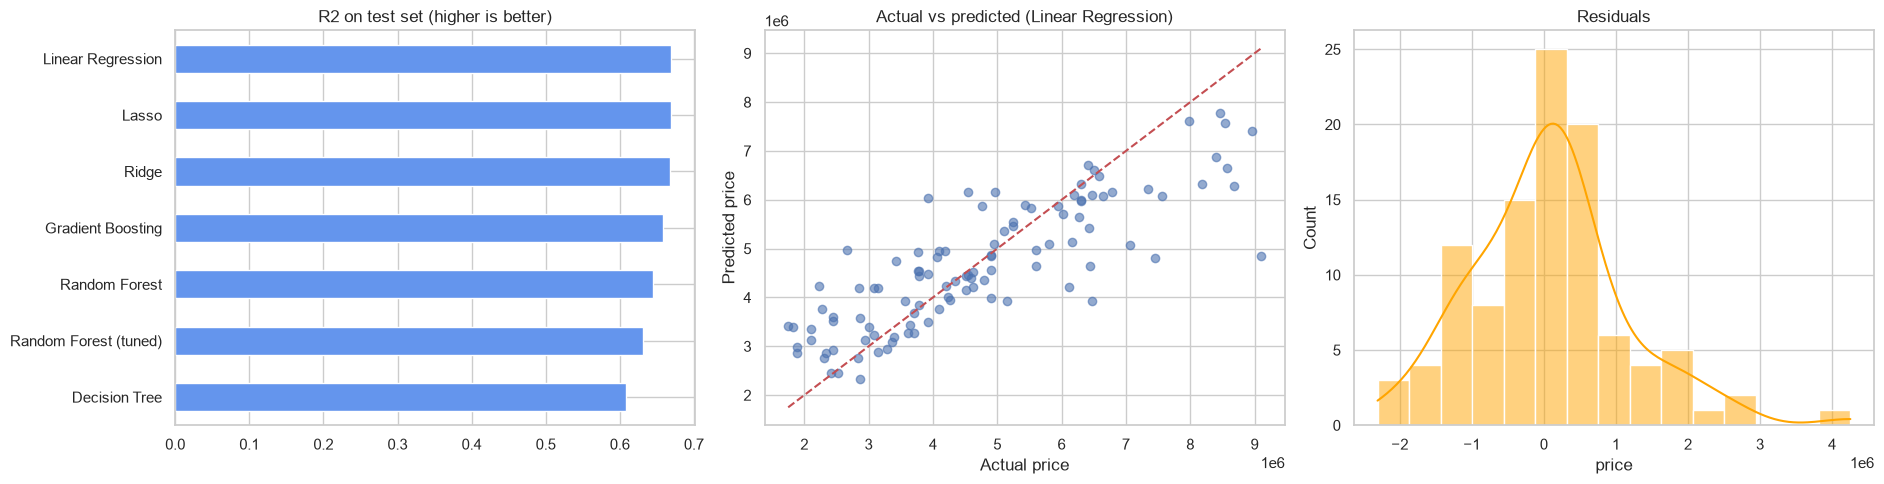

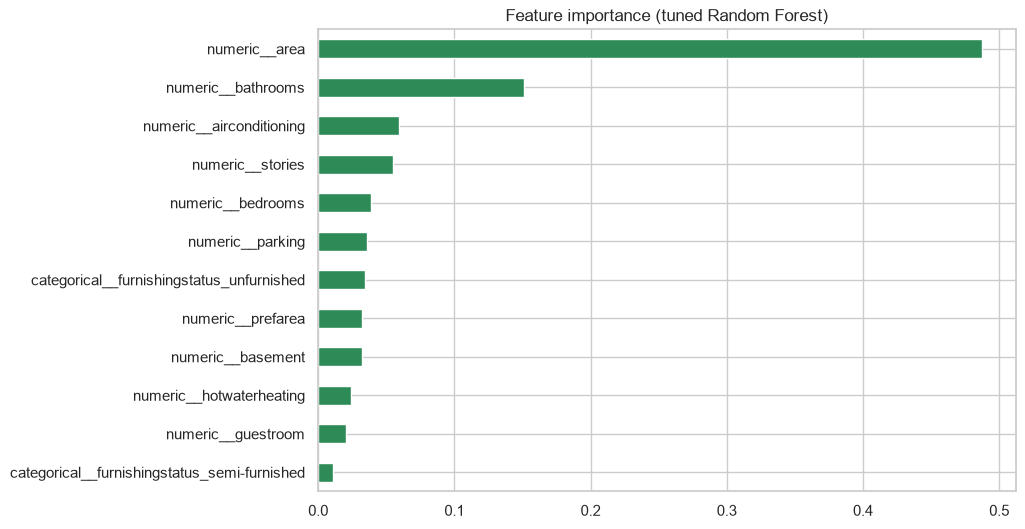

In [10]:
# Visualise results 
final_scores = {n: r2_score(y_test, m.predict(X_test)) for n, m in trained_models.items()}
best_model_name = max(final_scores, key=final_scores.get)
best_model = trained_models[best_model_name]
best_pred = best_model.predict(X_test)
print("Best model:", best_model_name, "| R2 =", round(final_scores[best_model_name], 3))
print("MAE :", round(mean_absolute_error(y_test, best_pred)))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, best_pred))))

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
pd.Series(final_scores).sort_values().plot(kind="barh", ax=axes[0], color="cornflowerblue")
axes[0].set_title("R2 on test set (higher is better)")
axes[1].scatter(y_test, best_pred, alpha=0.6)
lims = [y_test.min(), y_test.max()]
axes[1].plot(lims, lims, "r--")
axes[1].set_xlabel("Actual price"); axes[1].set_ylabel("Predicted price")
axes[1].set_title(f"Actual vs predicted ({best_model_name})")
sns.histplot(y_test - best_pred, kde=True, ax=axes[2], color="orange")
axes[2].set_title("Residuals")
plt.tight_layout()
plt.show()

feature_names = tuned_forest.named_steps["prep"].get_feature_names_out()
importances = pd.Series(tuned_forest.named_steps["model"].feature_importances_,
                        index=feature_names)
importances.sort_values().tail(12).plot(kind="barh", figsize=(9, 6), color="seagreen")
plt.title("Feature importance (tuned Random Forest)")
plt.show()


In [11]:
# Save model and predict a new house 
joblib.dump(best_model, "house_price_model.joblib")
loaded_model = joblib.load("house_price_model.joblib")

new_house = pd.DataFrame([{
    "area": 6000, "bedrooms": 3, "bathrooms": 2, "stories": 2,
    "mainroad": 1, "guestroom": 0, "basement": 1, "hotwaterheating": 0,
    "airconditioning": 1, "parking": 2, "prefarea": 1,
    "furnishingstatus": "semi-furnished",
}])
print("Predicted price: {:,.0f}".format(loaded_model.predict(new_house)[0]))

Predicted price: 6,902,498


In [12]:
# Final accuracy summary 
r2_pct = r2_score(y_test, best_pred) * 100
mape = np.mean(np.abs((y_test - best_pred) / y_test)) * 100
within_10_pct = (np.abs((y_test - best_pred) / y_test) <= 0.10).mean() * 100
within_20_pct = (np.abs((y_test - best_pred) / y_test) <= 0.20).mean() * 100

print("=" * 55)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 55)
print(f"Best model               : {best_model_name}")
print(f"R2 score                 : {r2_pct:.2f}%  (price variation explained)")
print(f"MAE                      : {mean_absolute_error(y_test, best_pred):,.0f}")
print(f"RMSE                     : {np.sqrt(mean_squared_error(y_test, best_pred)):,.0f}")
print(f"Average error (MAPE)     : {mape:.2f}%")
print(f"Prediction accuracy      : {100 - mape:.2f}%  (100 - MAPE)")
print(f"Predictions within ±10%  : {within_10_pct:.2f}% of houses")
print(f"Predictions within ±20%  : {within_20_pct:.2f}% of houses")
print("=" * 55)

FINAL MODEL PERFORMANCE SUMMARY
Best model               : Linear Regression
R2 score                 : 66.84%  (price variation explained)
MAE                      : 784,877
RMSE                     : 1,071,543
Average error (MAPE)     : 19.34%
Prediction accuracy      : 80.66%  (100 - MAPE)
Predictions within ±10%  : 45.28% of houses
Predictions within ±20%  : 66.98% of houses
